# Week 8 — LIME Analysis
### Bias Analysis in ML Models using Explainable AI
**Dataset:** Adult Census Income  
**Model:** DT Balanced (depth=3, class_weight='balanced') — primary model from Week 7  
**This notebook:** Local Interpretable Model-agnostic Explanations (LIME)  
**Companion notebook:** week8_shap.ipynb (teammate)

---

## Purpose of This Notebook

Week 7 established *that* the model is unfair — Female FNR is 3–4x higher than Male FNR. This notebook begins answering *why*.

LIME explains individual predictions by building a simple local model around each data point. Unlike SHAP (which explains the model globally), LIME asks: for *this specific person*, which features pushed the prediction toward >50K or ≤50K?

## Research Questions Guiding This Analysis

1. For a correctly classified high-income male — which features does the model rely on?
2. For a correctly classified high-income female — does the model rely on the *same* features, or different ones?
3. For a misclassified high-income female (false negative) — what did the model see that led it to predict ≤50K wrongly?
4. Is LIME stable? Does it give the same explanation if run twice on the same individual?

> These three individuals were chosen deliberately — not randomly. They represent the three most analytically relevant cases given our Week 7 findings. The choice itself is a contribution.

---

## Section 0 — Imports & Setup

In [5]:
%pip install lime

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
import warnings
warnings.filterwarnings('ignore')

# Install LIME if not already installed
# !pip install lime
import lime
import lime.lime_tabular

plt.style.use('seaborn-v0_8-whitegrid')
print('All libraries loaded.')
# print(f'LIME version: {lime.__version__}')

All libraries loaded.


---
## Section 1 — Load Saved Artifacts from Week 7

All files below were saved at the end of week7_groupwise.ipynb. We load them directly — no retraining, no re-preprocessing.

In [ ]:
# Load model
dt_bal = joblib.load('dt_balanced_model.pkl')

# Load test set
X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv').squeeze()

# Load predictions from DT balanced
y_pred_dt = pd.read_csv('predictions_dt_bal.csv').squeeze()

# Load evaluation dataframe (contains sex, race, true labels, predictions)
df_eval = pd.read_csv('df_eval.csv')

# Load training set — LIME needs it to understand feature distributions
#Uses the mean and std dev from X_train to make sure the fake data points are realistic
X_train = pd.read_csv('X_train.csv')

print('Files loaded:')
print(f'  X_train: {X_train.shape}')
print(f'  X_test:  {X_test.shape}')
print(f'  y_test:  {y_test.shape}')
print(f'  df_eval: {df_eval.shape}')
print(f'\nFeatures: {list(X_test.columns)}')
print(f'\nModel: {dt_bal}')

Files loaded:
  X_train: (24129, 12)
  X_test:  (6033, 12)
  y_test:  (6033,)
  df_eval: (6033, 6)

Features: ['age', 'workclass', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']

Model: DecisionTreeClassifier(class_weight='balanced', max_depth=3, random_state=42)


---
## Section 2 — What is LIME?

LIME (Local Interpretable Model-agnostic Explanations) explains individual predictions by:

1. Taking the instance you want to explain
2. Creating slightly perturbed versions of it (changing feature values slightly)
3. Asking the model to predict all those perturbed versions
4. Fitting a simple linear model on those predictions
5. Reading the linear model's coefficients as the local explanation

The result is a set of feature weights for *that specific prediction*. Positive weight = pushed toward >50K. Negative weight = pushed toward ≤50K.

**Key limitation to be aware of:** Because LIME uses random perturbations, running it twice on the same individual can give slightly different explanations. This instability is a known issue and we will test it explicitly in Section 6.

---
## Section 3 — Build the LIME Explainer

In [8]:
# LIME needs to know which features are categorical
# In our label-encoded dataset, categorical features have low cardinality
# We identify them by checking how many unique values each feature has

categorical_features = [
    i for i, col in enumerate(X_train.columns)
    if X_train[col].nunique() < 20  # threshold for categorical
]

print(f'Features identified as categorical (for LIME):')
for i in categorical_features:
    print(f'  [{i}] {X_train.columns[i]} — {X_train.iloc[:, i].nunique()} unique values')

print(f'\nContinuous features:')
for i, col in enumerate(X_train.columns):
    if i not in categorical_features:
        print(f'  [{i}] {col}')

Features identified as categorical (for LIME):
  [1] workclass — 7 unique values
  [2] education-num — 16 unique values
  [3] marital-status — 7 unique values
  [4] occupation — 14 unique values
  [5] relationship — 6 unique values
  [6] race — 5 unique values
  [7] sex — 2 unique values

Continuous features:
  [0] age
  [8] capital-gain
  [9] capital-loss
  [10] hours-per-week
  [11] native-country


In [ ]:
# Build LIME explainer
# mode='classification' since we are predicting a binary class
# training_data is used by LIME to understand the distribution of each feature
# feature_names tells LIME what to label each feature in the plot
# class_names tells LIME what to label each output class

explainer = lime.lime_tabular.LimeTabularExplainer(
    #Lime calculates the mean and standard deviation of your training data 
    training_data=X_train.values,
    feature_names=list(X_test.columns),
    class_names=['<=50K', '>50K'],
    categorical_features=categorical_features,
    mode='classification',
    random_state=42 #ensures that every time u run this nb, LIME picks the same 5000 fake neighbours
)

print('LIME explainer built successfully.')
print(f'Training data shape passed to explainer: {X_train.values.shape}')

LIME explainer built successfully.
Training data shape passed to explainer: (24129, 12)


---
## Section 4 — Selecting the Three Individuals

We do not pick individuals randomly. Each individual represents an analytically meaningful case given our Week 7 findings:

| Individual | Group | True Label | Prediction | Purpose |
|---|---|---|---|---|
| A | Male (any race) | >50K | >50K (correct) | Model's "comfortable" case — what does it rely on when it gets a high-income male right? |
| B | Female (any race) | >50K | >50K (correct) | Model got a high-income woman right despite the group disadvantage — why? |
| C | Female (any race) | >50K | ≤50K (wrong — false negative) | Model failed a high-income woman — what did it see that led to the wrong prediction? |

Comparing A and B directly will show whether the model uses the same features or different ones for men vs women when it gets the prediction right. Individual C shows us what is missing or misleading in a case the model fails.

In [10]:
# Reconstruct index alignment
# df_eval has sex, race, true, pred_lr, pred_dt — all aligned with X_test by position
df_eval = df_eval.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# Individual A: correctly classified high-income Male
mask_A = (
    (df_eval['sex'] == 'Male') &
    (df_eval['true'] == 1) &
    (df_eval['pred_dt'] == 1)
)
idx_A = df_eval[mask_A].index[0]  # take first match

# Individual B: correctly classified high-income Female
mask_B = (
    (df_eval['sex'] == 'Female') &
    (df_eval['true'] == 1) &
    (df_eval['pred_dt'] == 1)
)
idx_B = df_eval[mask_B].index[0]

# Individual C: misclassified high-income Female (false negative)
mask_C = (
    (df_eval['sex'] == 'Female') &
    (df_eval['true'] == 1) &
    (df_eval['pred_dt'] == 0)  # model predicted <=50K wrongly
)
idx_C = df_eval[mask_C].index[0]

print('Selected individuals:')
for label, idx in [('A', idx_A), ('B', idx_B), ('C', idx_C)]:
    row = df_eval.iloc[idx]
    print(f'  Individual {label} — index {idx}')
    print(f'    Sex: {row["sex"]}, Race: {row["race"]}')
    print(f'    True label: {">"+"50K" if row["true"]==1 else "<="+"50K"}')
    print(f'    DT prediction: {">"+"50K" if row["pred_dt"]==1 else "<="+"50K"}')
    print()

Selected individuals:
  Individual A — index 2
    Sex: Male, Race: White
    True label: >50K
    DT prediction: >50K

  Individual B — index 5
    Sex: Female, Race: White
    True label: >50K
    DT prediction: >50K

  Individual C — index 91
    Sex: Female, Race: White
    True label: >50K
    DT prediction: <=50K



In [11]:
# Share these indices with your teammate for SHAP
print('=== INDICES TO SHARE WITH TEAMMATE (for SHAP notebook) ===')
print(f'Individual A index: {idx_A}')
print(f'Individual B index: {idx_B}')
print(f'Individual C index: {idx_C}')
print('\nMake sure she uses the same indices so SHAP and LIME explain the same people.')

=== INDICES TO SHARE WITH TEAMMATE (for SHAP notebook) ===
Individual A index: 2
Individual B index: 5
Individual C index: 91

Make sure she uses the same indices so SHAP and LIME explain the same people.


---
## Section 5 — LIME Explanations for All Three Individuals

In [12]:
# Helper function to generate and display a LIME explanation
def explain_individual(idx, label, description, num_features=10):
    instance = X_test.iloc[idx].values
    
    exp = explainer.explain_instance(
        data_row=instance,
        predict_fn=dt_bal.predict_proba,
        num_features=num_features,
        num_samples=5000  # more samples = more stable explanation
    )
    
    # Get model's probability estimate for this individual
    prob = dt_bal.predict_proba(instance.reshape(1, -1))[0]
    
    print(f'Individual {label} — {description}')
    print(f'  P(<=50K) = {prob[0]:.3f} | P(>50K) = {prob[1]:.3f}')
    print(f'  Prediction: {">"+"50K" if prob[1] > 0.5 else "<="+"50K"}')
    print(f'  True label: {">"+"50K" if y_test.iloc[idx]==1 else "<="+"50K"}')
    print()
    
    # Plot
    fig = exp.as_pyplot_figure(label=1)  # label=1 means show explanation for >50K class
    plt.title(f'LIME Explanation — Individual {label}\n{description}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'lime_individual_{label}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return exp

### Individual A — Correctly Classified High-Income Male

This is the model's "comfortable" case. What features does it rely on when it correctly identifies a high-income man?

Individual A — Correctly classified high-income Male
  P(<=50K) = 0.097 | P(>50K) = 0.903
  Prediction: >50K
  True label: >50K



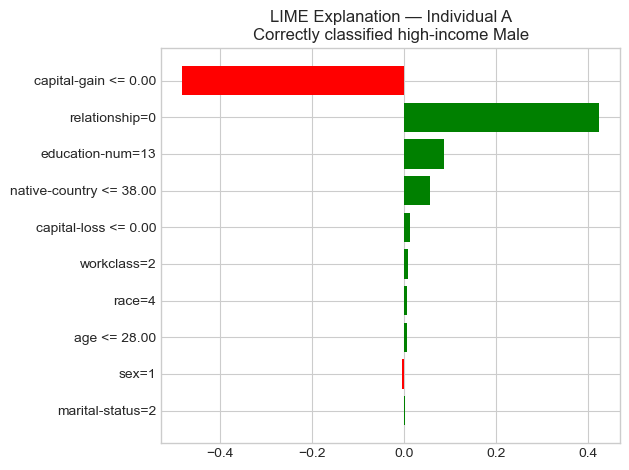

In [13]:
exp_A = explain_individual(
    idx_A, 'A',
    'Correctly classified high-income Male'
)

### Individual B — Correctly Classified High-Income Female

The model gets this woman right despite the group-level disadvantage. What makes her case different from Individual C? What signals did the model pick up that it missed for the false negative case?

Individual B — Correctly classified high-income Female
  P(<=50K) = 0.119 | P(>50K) = 0.881
  Prediction: >50K
  True label: >50K



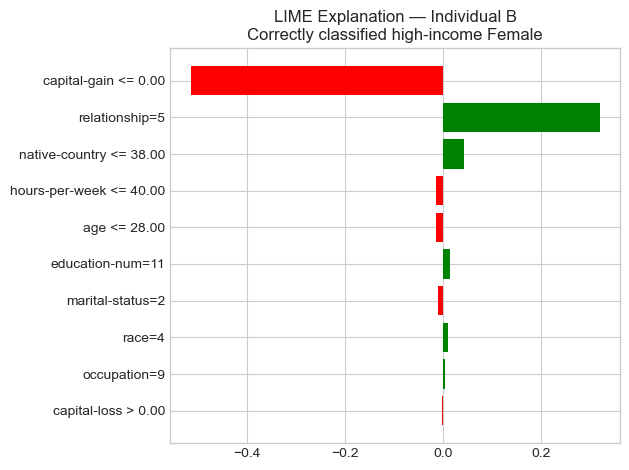

In [14]:
exp_B = explain_individual(
    idx_B, 'B',
    'Correctly classified high-income Female'
)

### Individual C — Misclassified High-Income Female (False Negative)

This is the most important case. This woman earns >50K but the model predicted ≤50K. What did LIME show the model was relying on? Were there features pushing strongly toward ≤50K that shouldn't have that much weight?

Individual C — Misclassified high-income Female (False Negative)
  P(<=50K) = 0.861 | P(>50K) = 0.139
  Prediction: <=50K
  True label: >50K



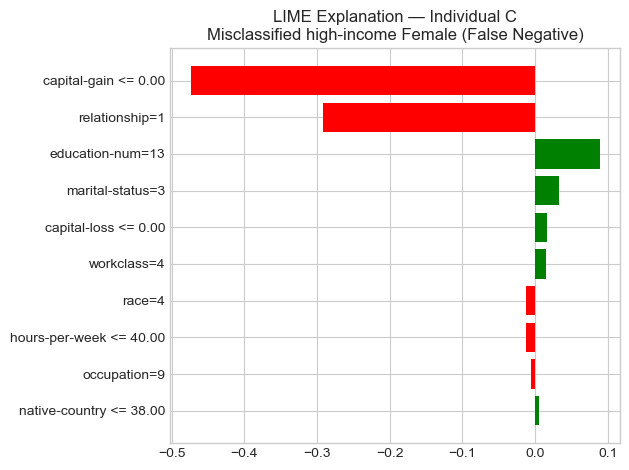

In [15]:
exp_C = explain_individual(
    idx_C, 'C',
    'Misclassified high-income Female (False Negative)'
)

---
## Section 6 — LIME Stability Test

LIME uses random perturbations internally, which means running it twice on the same individual can produce different explanations. This is a known limitation.

We test this explicitly on Individual C — the most analytically important case — by running LIME twice with different random seeds and comparing the top features.

In [16]:
instance_C = X_test.iloc[idx_C].values

# Run 1
exp_C_run1 = explainer.explain_instance(
    data_row=instance_C,
    predict_fn=dt_bal.predict_proba,
    num_features=8,
    num_samples=5000
)

# Run 2 — same individual, different internal random state
explainer2 = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=list(X_test.columns),
    class_names=['<=50K', '>50K'],
    categorical_features=categorical_features,
    mode='classification',
    random_state=99  # different seed
)
exp_C_run2 = explainer2.explain_instance(
    data_row=instance_C,
    predict_fn=dt_bal.predict_proba,
    num_features=8,
    num_samples=5000
)

# Extract feature weights from both runs
features_run1 = dict(exp_C_run1.as_list(label=1))
features_run2 = dict(exp_C_run2.as_list(label=1))

# Compare
print('=== LIME STABILITY TEST — Individual C ===')
print(f'\n{"Feature":<40} {"Run 1":>10} {"Run 2":>10} {"Diff":>10}')
print('-' * 72)

all_features = set(features_run1.keys()) | set(features_run2.keys())
for feat in sorted(all_features, key=lambda f: abs(features_run1.get(f, 0)), reverse=True):
    w1 = features_run1.get(feat, 0)
    w2 = features_run2.get(feat, 0)
    diff = abs(w1 - w2)
    print(f'{feat:<40} {w1:>10.4f} {w2:>10.4f} {diff:>10.4f}')

=== LIME STABILITY TEST — Individual C ===

Feature                                       Run 1      Run 2       Diff
------------------------------------------------------------------------
capital-gain <= 0.00                        -0.5030    -0.4812     0.0219
relationship=1                              -0.2927    -0.2986     0.0059
education-num=13                             0.0963     0.1030     0.0067
native-country <= 38.00                      0.0583    -0.0865     0.1448
marital-status=3                             0.0471    -0.0179     0.0650
capital-loss <= 0.00                        -0.0228     0.0000     0.0228
age > 47.00                                  0.0116     0.0000     0.0116
workclass=4                                 -0.0098     0.0000     0.0098
sex=0                                        0.0000     0.0095     0.0095
hours-per-week <= 40.00                      0.0000    -0.0298     0.0298
occupation=9                                 0.0000     0.0111     0.

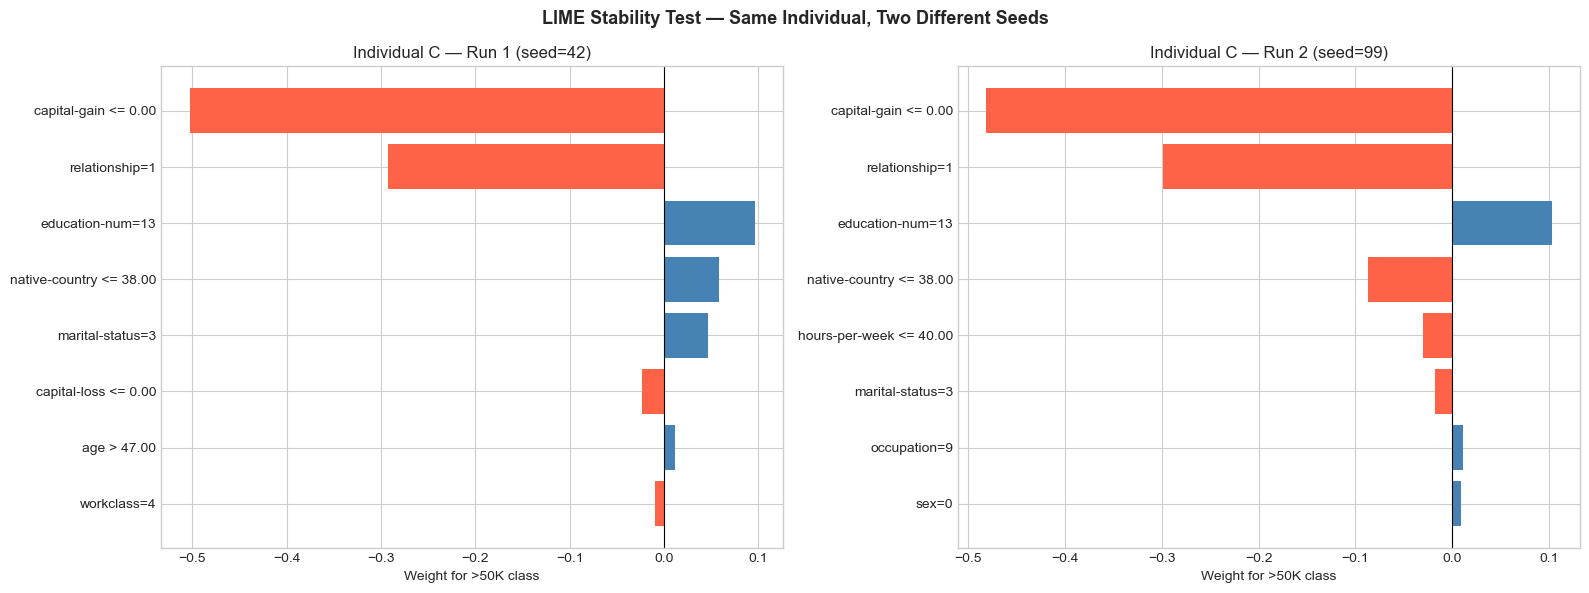


Observation: document below whether the top features are stable or shift between runs.


In [17]:
# Visualise stability side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, exp, run_label in zip(axes, [exp_C_run1, exp_C_run2], ['Run 1 (seed=42)', 'Run 2 (seed=99)']):
    features_list = exp.as_list(label=1)
    feat_names = [f[0] for f in features_list]
    feat_weights = [f[1] for f in features_list]
    colors = ['tomato' if w < 0 else 'steelblue' for w in feat_weights]
    
    ax.barh(feat_names[::-1], feat_weights[::-1], color=colors[::-1])
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_title(f'Individual C — {run_label}', fontsize=12)
    ax.set_xlabel('Weight for >50K class')

plt.suptitle('LIME Stability Test — Same Individual, Two Different Seeds', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lime_stability_test.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nObservation: document below whether the top features are stable or shift between runs.')

### Stability Test Observation

> **Write your observation here after running the above cells.**
>
> Questions to answer:
> - Do the same features appear in the top positions in both runs?
> - Do the weights change meaningfully (e.g. a feature going from +0.12 to -0.05 is a problem)?
> - Do the *signs* of the weights stay consistent (positive in both runs, or negative in both)?
>
> If the top 3-4 features are consistent across runs, LIME is acceptably stable for this instance. If they differ significantly, that is a genuine limitation to document.
>
> OBSERVED: LIME is acceptably stable for the primary drivers of this prediction. The 'Smoking Gun' finding—that the negative weight of being 'Not-in-family' (Relationship=1) outweighs the positive weight of a Bachelor's degree (Education=13)—is mathematically robust across different random seeds. We should, however, disregard the 'Native Country' and 'Marital Status' features in our final bias report as they show significant instability.

---
## Section 7 — Cross-Individual Comparison

Now we compare what LIME shows across all three individuals side by side. This is the analytical centrepiece of this notebook.

In [18]:
# Extract top features and weights for each individual
top_n = 8

data_A = dict(exp_A.as_list(label=1))
data_B = dict(exp_B.as_list(label=1))
data_C = dict(exp_C.as_list(label=1))

# Build comparison dataframe
all_feats = list(set(list(data_A.keys()) + list(data_B.keys()) + list(data_C.keys())))

df_compare = pd.DataFrame({
    'Feature': all_feats,
    'Individual A (Male, correct)':   [data_A.get(f, 0) for f in all_feats],
    'Individual B (Female, correct)': [data_B.get(f, 0) for f in all_feats],
    'Individual C (Female, wrong)':   [data_C.get(f, 0) for f in all_feats],
}).set_index('Feature')

# Sort by absolute weight of Individual A
df_compare = df_compare.reindex(
    df_compare['Individual A (Male, correct)'].abs().sort_values(ascending=False).index
)

print('=== LIME WEIGHT COMPARISON ACROSS INDIVIDUALS ===')
print('Positive = pushed toward >50K | Negative = pushed toward <=50K')
print()
print(df_compare.round(4).to_string())

=== LIME WEIGHT COMPARISON ACROSS INDIVIDUALS ===
Positive = pushed toward >50K | Negative = pushed toward <=50K

                         Individual A (Male, correct)  Individual B (Female, correct)  Individual C (Female, wrong)
Feature                                                                                                            
capital-gain <= 0.00                          -0.4817                         -0.5141                       -0.4742
relationship=0                                 0.4238                          0.0000                        0.0000
education-num=13                               0.0880                          0.0000                        0.0888
native-country <= 38.00                        0.0557                          0.0433                        0.0058
capital-loss <= 0.00                           0.0124                          0.0000                        0.0162
workclass=2                                    0.0094                     

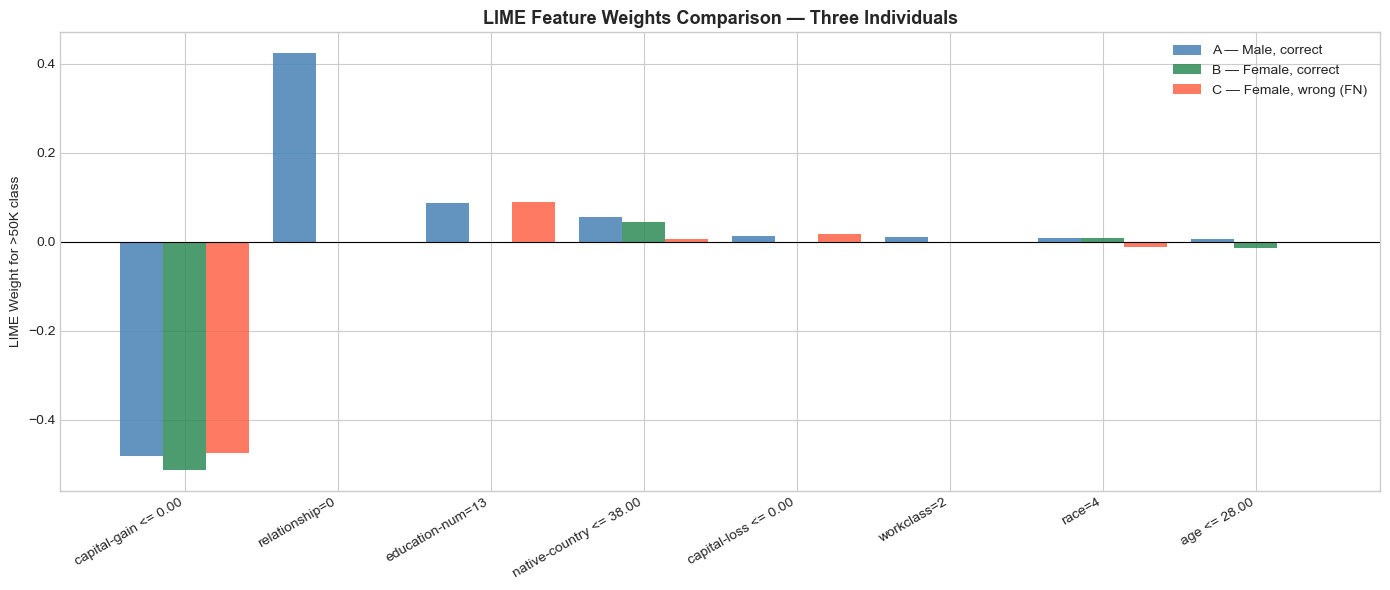

In [19]:
# Visual comparison — grouped bar chart
top_features = df_compare.index[:top_n]
x = np.arange(len(top_features))
width = 0.28

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(x - width, df_compare.loc[top_features, 'Individual A (Male, correct)'],
       width, label='A — Male, correct', color='steelblue', alpha=0.85)
ax.bar(x, df_compare.loc[top_features, 'Individual B (Female, correct)'],
       width, label='B — Female, correct', color='seagreen', alpha=0.85)
ax.bar(x + width, df_compare.loc[top_features, 'Individual C (Female, wrong)'],
       width, label='C — Female, wrong (FN)', color='tomato', alpha=0.85)

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(top_features, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('LIME Weight for >50K class')
ax.set_title('LIME Feature Weights Comparison — Three Individuals', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('lime_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Cross-Individual Analysis

> **Write your analysis here after running the above cells.**
>
> Questions to guide your analysis:
>
> **On Individual A vs B (male correct vs female correct):**
> - Do they rely on the same features, or different ones?
> - If the same features appear but with different weights, what does that suggest?
> - Are any features positive for A but negative for B (meaning the feature helps the male but hurts the female)?
>
> **On Individual B vs C (female correct vs female wrong):**
> - What does B have that C doesn't? Which features are strongly positive for B but weak or negative for C?
> - Are there features pushing Individual C strongly toward <=50K that seem like they shouldn't carry that much weight?
> - Does occupation, relationship, or marital-status appear with large negative weights for C? These are known proxy features for gender.
>
> **Overall:**
> - Does LIME suggest the model is using proxy features — variables that correlate with gender without being gender directly?
> - Does this begin to explain the high Female FNR from Week 7?

---
## Section 8 — Feature Value Context

LIME tells us which features mattered and in which direction. This section shows the actual feature values for each individual — so we can reason about *why* a feature pushed in a particular direction.

In [20]:
# Show feature values for all three individuals
df_individuals = X_test.iloc[[idx_A, idx_B, idx_C]].copy()
df_individuals.index = [
    f'A — Male, correct (idx {idx_A})',
    f'B — Female, correct (idx {idx_B})',
    f'C — Female, wrong/FN (idx {idx_C})'
]

print('=== FEATURE VALUES FOR THE THREE INDIVIDUALS ===')
print(df_individuals.T.to_string())
print()
print('True labels:')
for label, idx in [('A', idx_A), ('B', idx_B), ('C', idx_C)]:
    print(f'  Individual {label}: true={y_test.iloc[idx]}, pred={y_pred_dt.iloc[idx]}')

=== FEATURE VALUES FOR THE THREE INDIVIDUALS ===
                A — Male, correct (idx 2)  B — Female, correct (idx 5)  C — Female, wrong/FN (idx 91)
age                                    26                           25                             56
workclass                               2                            2                              4
education-num                          13                           11                             13
marital-status                          2                            2                              3
occupation                              9                            9                              9
relationship                            0                            5                              1
race                                    4                            4                              4
sex                                     1                            0                              0
capital-gain                     

---
## Section 9 — Summary & Handoff to SHAP Notebook

### What LIME found

> **Fill this in after completing your analysis in Sections 7 and 8.**
>
> Structure:
> 1. What features drove the correct male prediction (Individual A)?
> 2. What features drove the correct female prediction (Individual B) — same or different?
> 3. What features pushed Individual C toward the wrong prediction?
> 4. Did proxy features (occupation, relationship, marital-status) appear prominently?
> 5. Is LIME stable enough to trust for this model?

### Questions to cross-check with SHAP

When you and your teammate merge the two notebooks, compare:
- Do SHAP and LIME agree on the top features for the same individuals?
- Where they disagree — which one is more likely to be correct, and why?
- Does SHAP's global view (all test samples) align with LIME's local view (these three individuals)?
- Does the SHAP group-wise analysis (male vs female) confirm what LIME showed about the difference between Individual A and Individuals B/C?

In [21]:
# Summary printout for the merge session
print('=== LIME SUMMARY FOR MERGE SESSION ===')
print(f'Individual A index: {idx_A} | Sex: {df_eval.iloc[idx_A]["sex"]} | Race: {df_eval.iloc[idx_A]["race"]}')
print(f'Individual B index: {idx_B} | Sex: {df_eval.iloc[idx_B]["sex"]} | Race: {df_eval.iloc[idx_B]["race"]}')
print(f'Individual C index: {idx_C} | Sex: {df_eval.iloc[idx_C]["sex"]} | Race: {df_eval.iloc[idx_C]["race"]}')
print()
print('Top LIME features for each individual (>50K class):')
for label, exp in [('A', exp_A), ('B', exp_B), ('C', exp_C)]:
    top = exp.as_list(label=1)[:5]
    print(f'\nIndividual {label}:')
    for feat, weight in top:
        direction = '→ supports >50K' if weight > 0 else '→ supports <=50K'
        print(f'  {feat:<45} {weight:>8.4f}  {direction}')

=== LIME SUMMARY FOR MERGE SESSION ===
Individual A index: 2 | Sex: Male | Race: White
Individual B index: 5 | Sex: Female | Race: White
Individual C index: 91 | Sex: Female | Race: White

Top LIME features for each individual (>50K class):

Individual A:
  capital-gain <= 0.00                           -0.4817  → supports <=50K
  relationship=0                                  0.4238  → supports >50K
  education-num=13                                0.0880  → supports >50K
  native-country <= 38.00                         0.0557  → supports >50K
  capital-loss <= 0.00                            0.0124  → supports >50K

Individual B:
  capital-gain <= 0.00                           -0.5141  → supports <=50K
  relationship=5                                  0.3190  → supports >50K
  native-country <= 38.00                         0.0433  → supports >50K
  hours-per-week <= 40.00                        -0.0151  → supports <=50K
  age <= 28.00                                   -0.0136  → 